In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import tenpy
import tenpy.linalg.np_conserved as npc
from tenpy import version as v
print(v.version_summary)

from tenpy.networks.site import BosonSite, SpinSite, GroupedSite, set_common_charges
from tenpy.models.lattice import Lattice, IrregularLattice
from tenpy.models.model import CouplingModel
import tenpy.models.lattice as lattice

from tenpy.networks.mps import MPS
from tenpy.algorithms import tebd, dmrg, tdvp

from tenpy.algorithms.mpo_evolution import ExpMPOEvolution
from tenpy.algorithms.exact_diag import ExactDiag
from tenpy.algorithms.dmrg import TwoSiteDMRGEngine
from tenpy.algorithms.tebd import TEBDEngine


import time
import os
import json
from matplotlib import cm


tenpy 1.1.0 (compiled without HAVE_MKL),
git revision ae3019b4cc47b5ce98a886ac163da5fd2ecddd67 using
python 3.12.13 (main, May 10 2026, 19:30:01) [Clang 22.1.3 ]
numpy 2.5.0, scipy 1.18.0


In [2]:
from SpinBosonEnv.GeneralSpinBosonEnv import GeneralSpinBosonEnv
from SpinBosonEnv.CavityArrayAtom import CavityArrayAtom

In [19]:
a = (2,2)
tuple(a)


(2, 2)

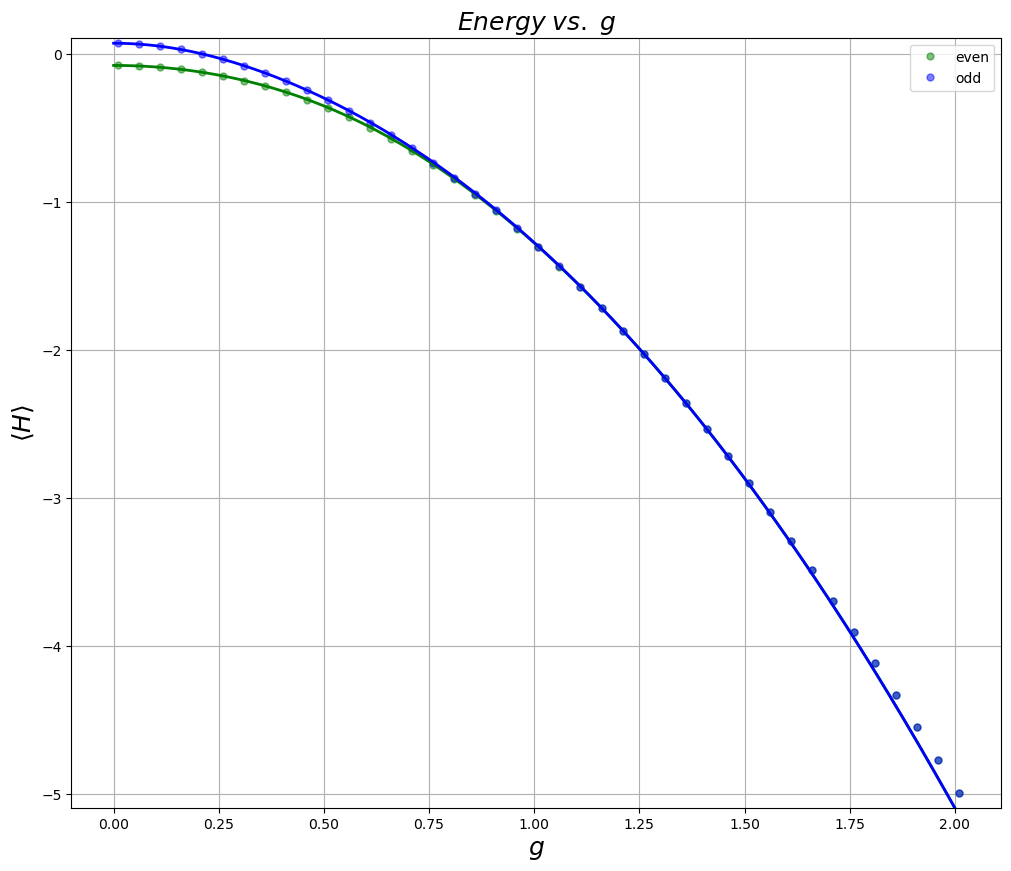

In [83]:
import matplotlib.pyplot as plt
import json
import pickle as pkl
import numpy as np

artifact_paths= [
"/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/d620b4a9/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.1500_UUID_d620b4a9.json",
"/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/040dd4d6/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.1500_UUID_040dd4d6.json"
]

color = ["green", "blue"]
paridad = ["even", "odd"]


fig, ax = plt.subplots(figsize=[12, 10])

y_min = np.inf
y_max = -np.inf
for i, artifact_path in enumerate(artifact_paths):
    

    with open(artifact_path, "r") as f:
        artifact = json.load(f)

    results_path = artifact["results"]["main_results"]
    # Load Main results .pkl
    with open(results_path, "rb") as f:
        data = pkl.load(f)

    # ENERGY
    gvals = data[:, 4]
    alphavals = data[:, 5]
    E_gr = data[:, 6]

    if E_gr.min() < y_min:
        y_min = E_gr.min()
    if E_gr.max() > y_max:
        y_max = E_gr.max()

    plot_setup = {"use_alpha":False}

    x_data = alphavals if plot_setup["use_alpha"] else gvals
    coup_label = r"alpha" if plot_setup["use_alpha"] else f"g"

    ax.plot(x_data, E_gr, color=color[i], label=rf"{paridad[i]}", ls="", marker='o', ms=5, alpha=0.5)
    
ax.set_title(rf"$Energy\;vs.\;{coup_label} \quad$", fontsize=18)
ax.set_xlabel(rf"${coup_label}$", fontsize=18)
ax.set_ylabel(r"$\langle H \rangle$", fontsize=18)
ax.set_ylim(y_min + y_min / 50, y_max + y_max / 2)
ax.grid()
ax.legend()

teo = np.loadtxt("/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/ground_first_energy_vs_coupling.txt").T

gs, _, E_even, E_odd, _ = teo

ax.plot(gs, E_even, color="green", lw=2)
ax.plot(gs, E_odd, color="blue", lw=2)

# ax.set_xlim(-0.01, 1.0)
# ax.set_ylim(-2.0, 0.5)

g: 0.060000000000000005
g: 0.060000000000000005


Text(0.4, 0.9, '$\\Delta = 0.150$\n$\\omega_c = 50.000$\n$\\omega_{\\min} = 0.500$')

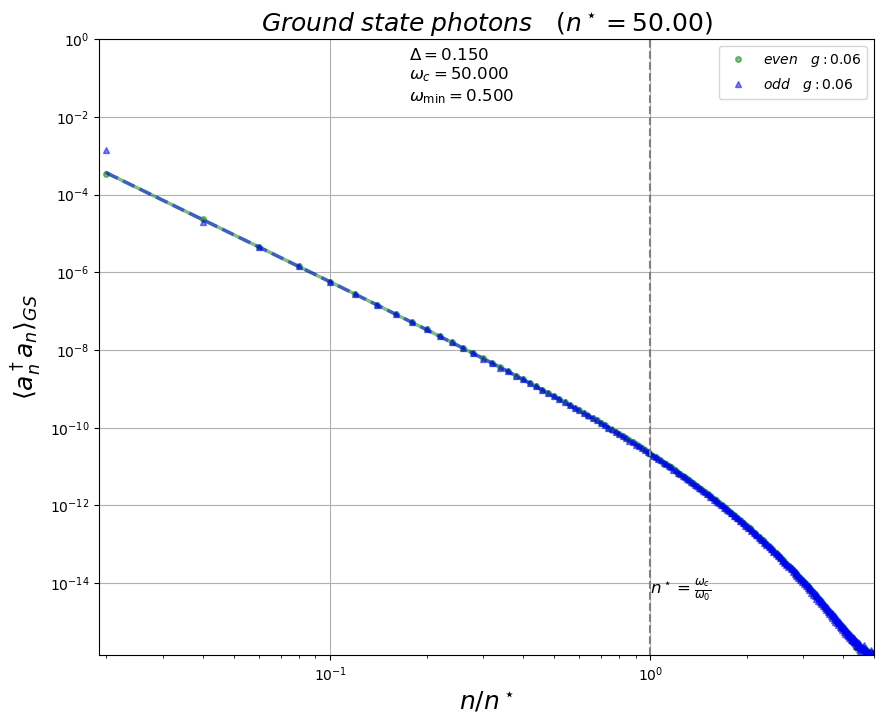

In [5]:
import matplotlib.pyplot as plt
import json
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import numpy as np
import scipy

gval = 1

artifact_paths= [
"/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/d620b4a9/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.1500_UUID_d620b4a9.json",
"/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/040dd4d6/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.1500_UUID_040dd4d6.json"
]

color = ["green", "blue"]
paridad = ["even", "odd"]
marker_mps = ["o", "^"]
ls_teo = ["-", "--"]

fig1, ax1 = plt.subplots(figsize=[10, 8])

y_min = np.inf
y_max = -np.inf
for i, artifact_path in enumerate(artifact_paths):    

    with open(artifact_path, "r") as f:
        artifact = json.load(f)

    results_path = artifact["results"]["main_results"]
    # Load Main results .pkl
    with open(results_path, "rb") as f:
        data = pkl.load(f)

    w0 = int(data[:, 0][0])
    delta = float(data[:, 1][0])
    wc = int(data[:, 2][0])
    Nk = int(data[:, 3][0])

    gvals = data[:, 4][gval]
    alphavals = data[:, 5][gval]
    Sz = data[:, 9]
    print(f"g: {gvals}")

    indexes = gval

    plot_setup = {"use_alpha":False}

    x_data = alphavals if plot_setup["use_alpha"] else gvals
    curve_label = r"\alpha" if plot_setup["use_alpha"] else r"g"
    nprime = wc / w0

    nprime = wc / w0
    ohmic_model = "SubSubOhmic"
    wmin = w0 * wc / np.sqrt(w0**2 + 4 * wc**2)

    field_path = artifact["results"]["field"]["x"][indexes]

    #FIELD
    Nx = np.loadtxt(
        field_path,
        dtype=complex,
    ).real

    Nxhalf = Nx[Nk // 2 :]
    n_values = np.arange(len(Nxhalf))
    if min(Nxhalf) < y_min:
        y_min = min(Nxhalf)

    # TEORIC
    if True:
        Nteo = (
            gvals**2
            / (np.pi**2 * w0**2 * nprime**2)
            * (scipy.special.k1(n_values / nprime) / n_values) ** 2
        )
        ax1.plot(np.arange(0, len(n_values)) / nprime, Nteo, color=color[i], ls=ls_teo[i], lw=2.5, alpha=0.5)

    # MPS RESULTS
    ax1.plot(
        np.arange(len(Nxhalf)) / nprime,
        Nxhalf,
        color=color[i],
        marker=marker_mps[i],
        ls="",
        ms=4,
        label=rf"${paridad[i]}\quad g:{gvals:.2f}$", alpha =0.5
    )

ymin=1e-15
ax1.set_ylim(y_min, 1e0)
ax1.vlines(1, y_min, 1e1, color="grey", ls="--")
ax1.legend()
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.grid()


ax1.set_title(
    r"$Ground\;state\;photons \quad (n^\star=%.2f)$" % (nprime), fontsize=18
)
ax1.set_xlabel(r"$n/n^\star$", fontsize=18)
ax1.set_ylabel(r"$\langle a_n^\dagger a_n \rangle_{GS}$", fontsize=18)
ax1.set_xlim(1 / nprime - 0.001, Nk // 2 / nprime)

ax1.text(
    1,
    0.1,
    r"$n^\star = \frac{\omega_c}{\omega_0}$",
    transform=transforms.blended_transform_factory(ax1.transData, ax1.transAxes),
    fontsize=12,
)
ax1.text(
    0.4,
    0.9,
    (
        rf"$\Delta = {delta:.3f}$"
        "\n"
        rf"$\omega_c = {wc:.3f}$"
        "\n"
        rf"$\omega_{{\min}} = {wmin:.3f}$"
    ),
    transform=transforms.blended_transform_factory(ax1.transAxes, ax1.transAxes),
    fontsize=12,
)



Theoretical expression for Sz uses 'g' as coupling strength
Hola
(4, 201)


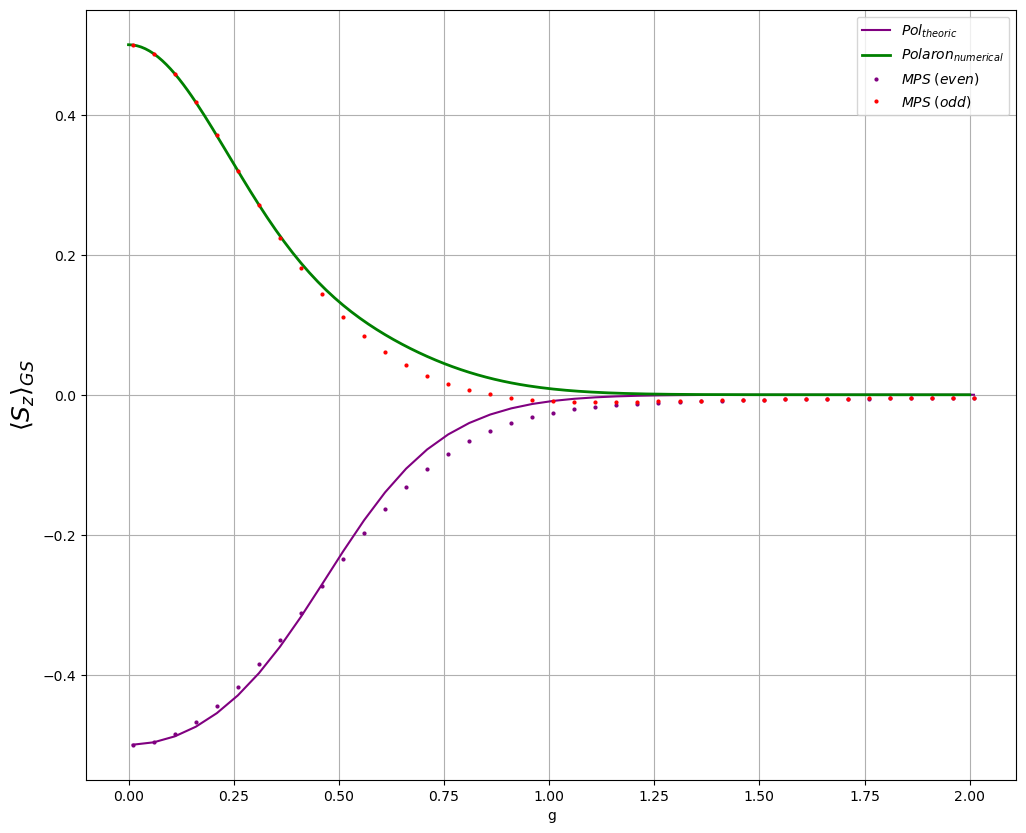

In [21]:
import matplotlib.pyplot as plt
import json
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import numpy as np
import scipy

from SpinBosonEnv.plots.Spin import calc_sz_teo
gval = 12

artifact_paths= [
"/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/d620b4a9/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.1500_UUID_d620b4a9.json",
"/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/040dd4d6/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.1500_UUID_040dd4d6.json"
]

color = ["purple", "red"]
paridad = ["even", "odd"]
marker_mps = ["o", "^"]
ls_teo = ["-", "--"]

fig, ax = plt.subplots(figsize=[12, 10])
if True:
    Sz_teo = calc_sz_teo(gvals, ohmic_model, w0, wc, delta)
    ax.plot(gvals, Sz_teo, color="purple", label=r"$Pol_{theoric}$")
    ax.grid()
    ax.legend()

#Numeric

teo = np.loadtxt("/home/ihuarte/Descargas/sigma_z_first_excited_vs_coupling.txt").T
print(teo.shape)
gs, _,  _, Sz_num = teo

ax.plot(gs, Sz_num*0.5, color="green", lw=2, label=r"$Polaron_{numerical}$")



for i, artifact_path in enumerate(artifact_paths):    

    with open(artifact_path, "r") as f:
        artifact = json.load(f)

    results_path = artifact["results"]["main_results"]
    # Load Main results .pkl
    with open(results_path, "rb") as f:
        data = pkl.load(f)

    w0 = int(data[:, 0][0])
    delta = float(data[:, 1][0])
    wc = int(data[:, 2][0])
    Nk = int(data[:, 3][0])
    ohmic_model = "SubSubOhmic"

    gvals = data[:, 4]
    alphavals = data[:, 5]
    indexes = gval

    Sz = data[:, 10] 

    plot_setup = {"use_alpha":False}

    x_data = alphavals if plot_setup["use_alpha"] else gvals
    curve_label = r"\alpha" if plot_setup["use_alpha"] else r"g"

    ax.set_ylabel(r"$\langle S_z \rangle_{GS}$", fontsize=18)
    ax.set_xlabel(rf"{curve_label}")

    ax.plot(x_data, Sz, color=color[i], ls="", marker="o", ms=2, label=r"$MPS\;(%s)$"%paridad[i])




ax.legend()

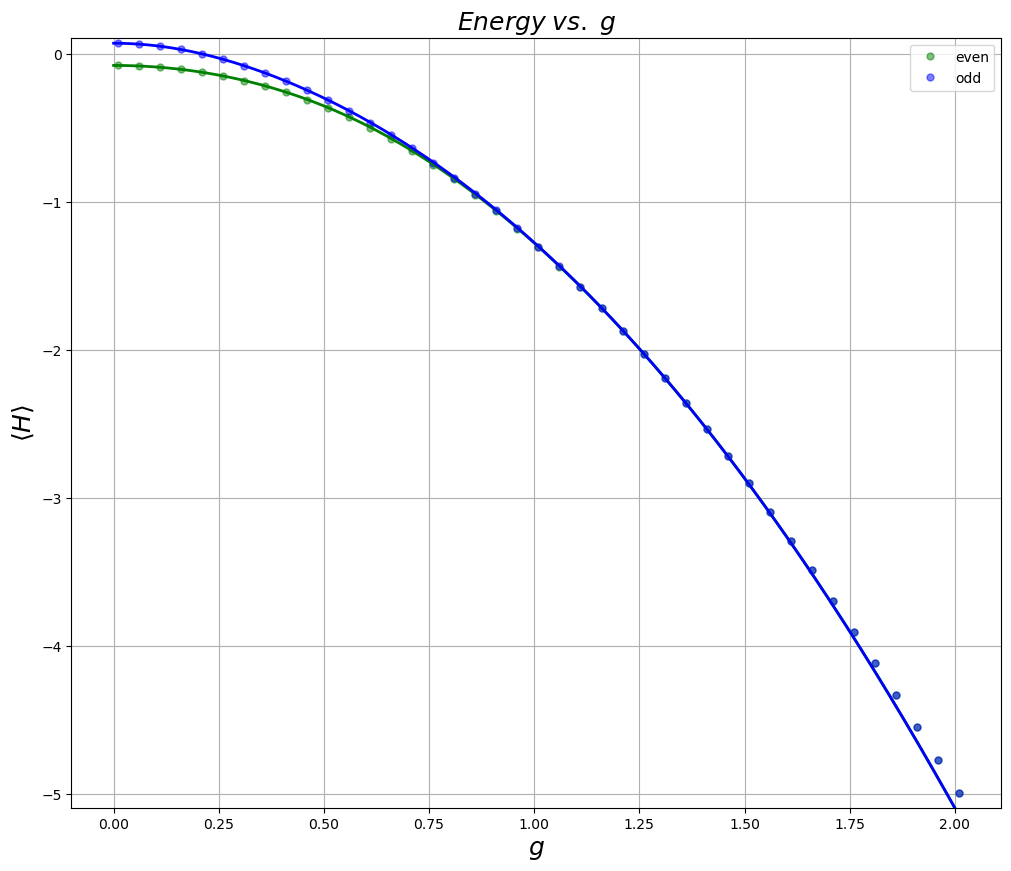

In [ ]:
import matplotlib.pyplot as plt
import json
import pickle as pkl
import numpy as np

artifact_paths= [
"/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/d620b4a9/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.1500_UUID_d620b4a9.json",
"/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/040dd4d6/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.1500_UUID_040dd4d6.json"
]

color = ["green", "blue"]
paridad = ["even", "odd"]


fig, ax = plt.subplots(figsize=[12, 10])

y_min = np.inf
y_max = -np.inf
for i, artifact_path in enumerate(artifact_paths):
    

    with open(artifact_path, "r") as f:
        artifact = json.load(f)

    results_path = artifact["results"]["main_results"]
    # Load Main results .pkl
    with open(results_path, "rb") as f:
        data = pkl.load(f)

    # ENERGY
    gvals = data[:, 4]
    alphavals = data[:, 5]
    E_gr = data[:, 6]

    if E_gr.min() < y_min:
        y_min = E_gr.min()
    if E_gr.max() > y_max:
        y_max = E_gr.max()

    plot_setup = {"use_alpha":False}

    x_data = alphavals if plot_setup["use_alpha"] else gvals
    coup_label = r"alpha" if plot_setup["use_alpha"] else f"g"

    ax.plot(x_data, E_gr, color=color[i], label=rf"{paridad[i]}", ls="", marker='o', ms=5, alpha=0.5)
    
ax.set_title(rf"$Energy\;vs.\;{coup_label} \quad$", fontsize=18)
ax.set_xlabel(rf"${coup_label}$", fontsize=18)
ax.set_ylabel(r"$\langle H \rangle$", fontsize=18)
ax.set_ylim(y_min + y_min / 50, y_max + y_max / 2)
ax.grid()
ax.legend()

teo = np.loadtxt("/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/ground_first_energy_vs_coupling.txt").T

gs, _, E_even, E_odd, _ = teo

ax.plot(gs, E_even, color="green", lw=2)
ax.plot(gs, E_odd, color="blue", lw=2)

# ax.set_xlim(-0.01, 1.0)
# ax.set_ylim(-2.0, 0.5)

0.6100000000000001
0.6100000000000001


In [ ]:
Nxs[1]-N

{'d620b4a9': ['/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/d620b4a9/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.1500_UUID_d620b4a9.json',
  '/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/d620b4a9/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.3000_UUID_d620b4a9.json'],
 '040dd4d6': ['/home/ihuarte/Escritorio/Ivan/MPS/Results_parity/SubSubOhmic/040dd4d6/Simulation_results_SubSubOhmic_w0_1.0000_wc_50.0000_Nk_501.0000_delta_0.1500_UUID_040dd4d6.json']}

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.0
delta: 10.0 Boson_dim: 10
**********************************************************
g0 0.0


/home/ihuarte/Escritorio/Ivan/MPS/SpinBosonEnv/GeneralSpinBosonEnv.py:95: RuntimeWarning: invalid value encountered in divide
  v0 = gks / g0


Hk: (302, 302)
Hmap: (302, 302)


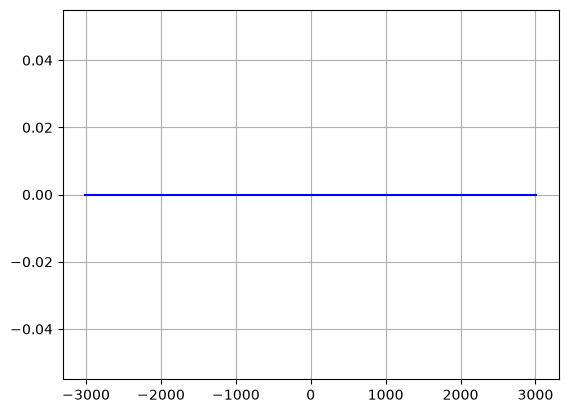

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.05
delta: 10.0 Boson_dim: 10
**********************************************************
g0 3.3582514071575424
Hk: (302, 302)
Hmap: (216, 216)


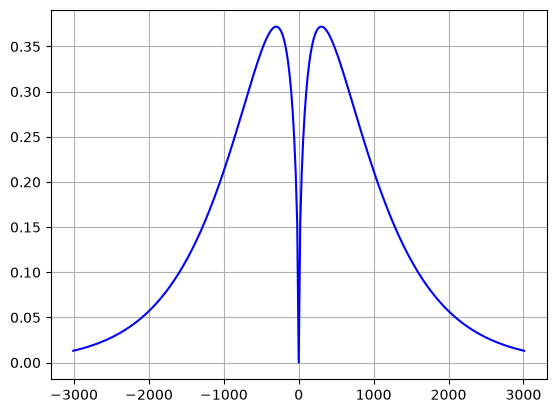

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.1
delta: 10.0 Boson_dim: 10
**********************************************************
g0 6.716502814315085
Hk: (302, 302)
Hmap: (216, 216)


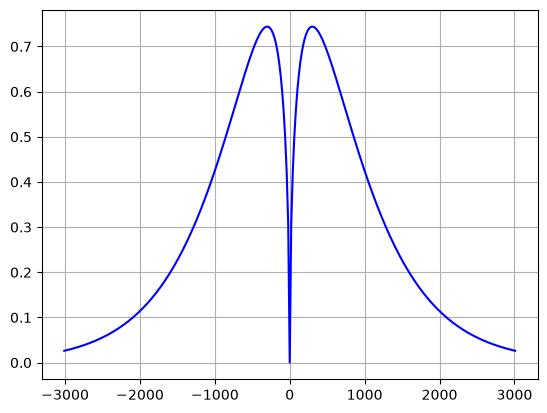

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.15000000000000002
delta: 10.0 Boson_dim: 10
**********************************************************
g0 10.074754221472627
Hk: (302, 302)
Hmap: (216, 216)


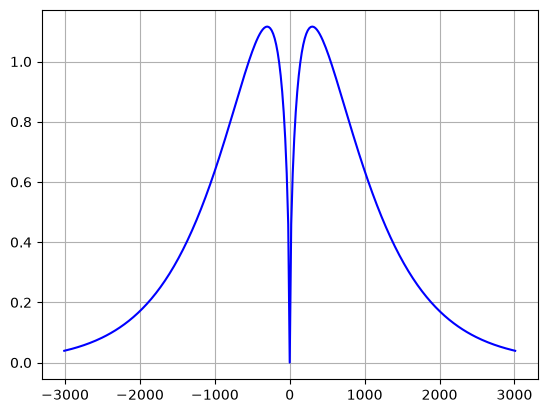

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.2
delta: 10.0 Boson_dim: 10
**********************************************************
g0 13.43300562863017
Hk: (302, 302)
Hmap: (216, 216)


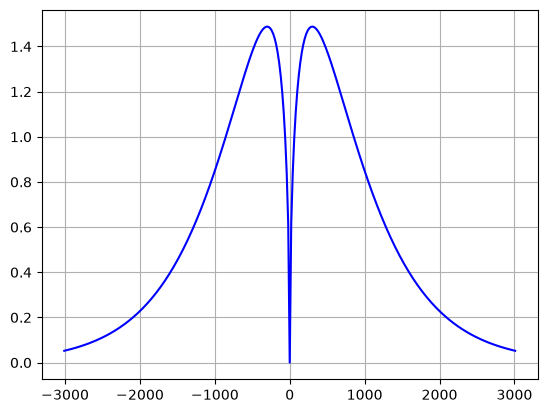

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.25
delta: 10.0 Boson_dim: 10
**********************************************************
g0 16.79125703578771
Hk: (302, 302)
Hmap: (216, 216)


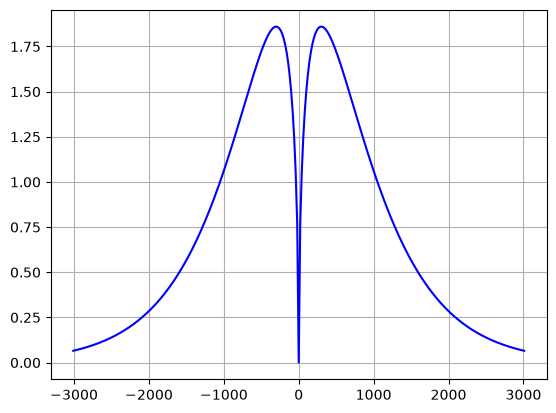

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.30000000000000004
delta: 10.0 Boson_dim: 10
**********************************************************
g0 20.149508442945255
Hk: (302, 302)
Hmap: (216, 216)


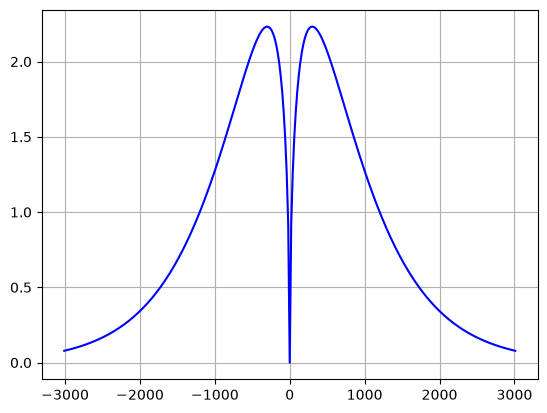

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.35000000000000003
delta: 10.0 Boson_dim: 10
**********************************************************
g0 23.5077598501028
Hk: (302, 302)
Hmap: (216, 216)


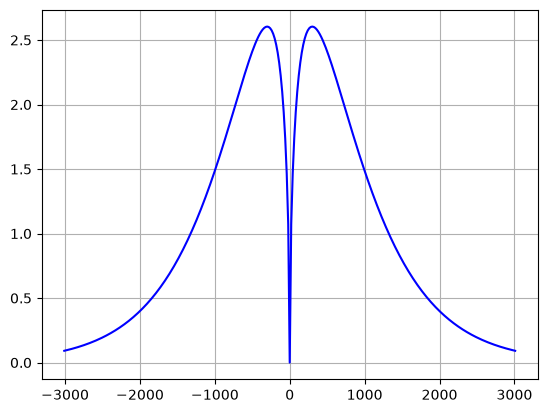

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.4
delta: 10.0 Boson_dim: 10
**********************************************************
g0 26.86601125726034
Hk: (302, 302)
Hmap: (216, 216)


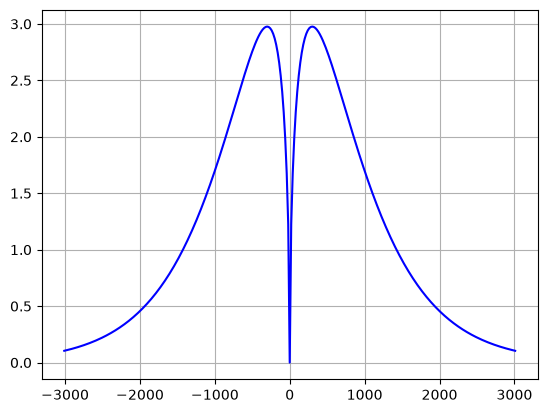

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.45
delta: 10.0 Boson_dim: 10
**********************************************************
g0 30.224262664417882
Hk: (302, 302)
Hmap: (216, 216)


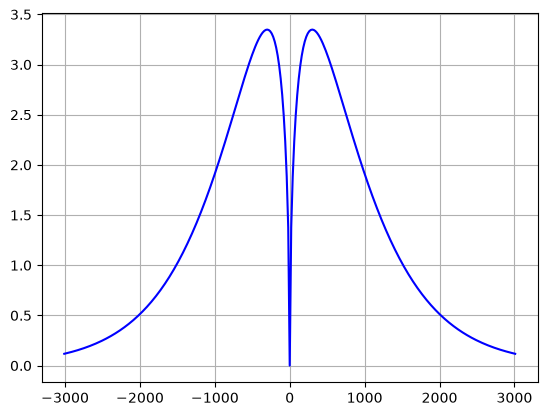

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.5
delta: 10.0 Boson_dim: 10
**********************************************************
g0 33.58251407157542
Hk: (302, 302)
Hmap: (216, 216)


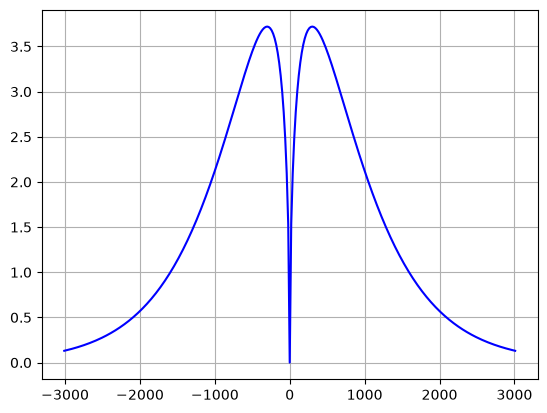

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.55
delta: 10.0 Boson_dim: 10
**********************************************************
g0 36.94076547873296
Hk: (302, 302)
Hmap: (216, 216)


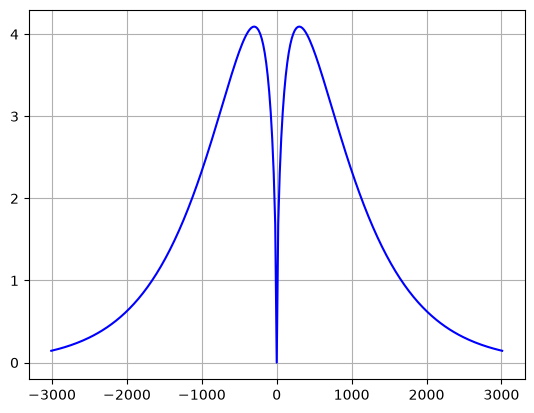

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.6000000000000001
delta: 10.0 Boson_dim: 10
**********************************************************
g0 40.29901688589051
Hk: (302, 302)
Hmap: (216, 216)


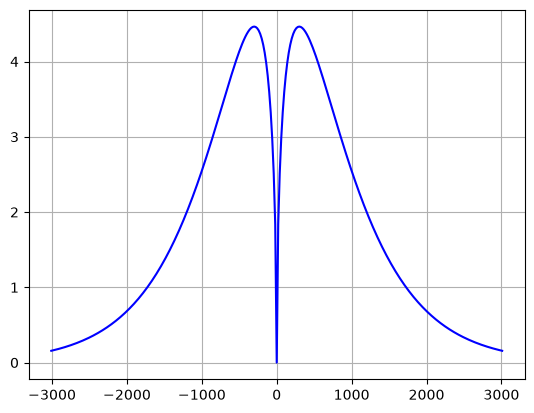

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.65
delta: 10.0 Boson_dim: 10
**********************************************************
g0 43.65726829304805
Hk: (302, 302)
Hmap: (216, 216)


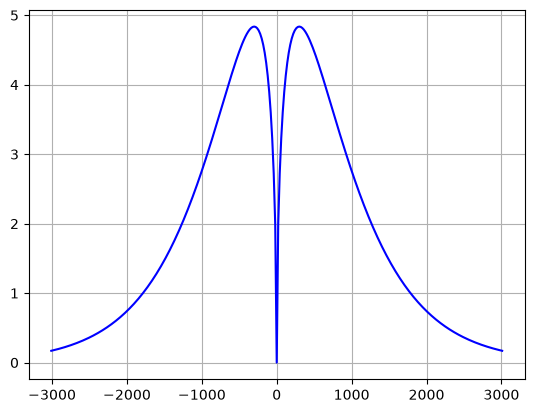

**********************************************************
w0: 1.0  wc: 20  Nk: 301 g: 0.7000000000000001
delta: 10.0 Boson_dim: 10
**********************************************************
g0 47.0155197002056
Hk: (302, 302)
Hmap: (216, 216)


KeyboardInterrupt: 

In [ ]:

with open("/home/ihuarte/Escritorio/Ivan/MPS/config.json", "r") as f:
    config = json.load(f)

SB_params = config["SB_params"]
model_params = config["model_params"]
DMRG_options = config["DMRG_options"]

for k, v in SB_params.items():
    SB_params[k] = np.pi if v == "pi" else v




# Run in parameters
Nk_list = [301]  # , 2501, 5001]

delta = 10.0
SB_params["delta"] = delta
lambda0 = 2 * np.pi / delta
L = lambda0 * 10
wc_list = [nk  / L for nk in Nk_list]
g_list = np.arange(0.0, 1.85, 0.05)

for wc, Nk in zip(wc_list, Nk_list):
    SB_params["wc"] = 301
    SB_params["Nk"] = Nk

    main_results = np.zeros((len(g_list), 10))

    for i, g in enumerate(g_list):
        SB_params["g"] = g

        print("**********************************************************")
        print(f"w0: {SB_params["w0"]}  wc: {wc}  Nk: {SB_params["Nk"]} g: {g}")
        print(f"delta: {SB_params["delta"]} Boson_dim: {model_params["N_max"]}")
        print("**********************************************************")

        # Spin Boson model init
        env_SB = GeneralSpinBosonEnv(SB_params)
        print(f"Hk: {env_SB.Hk.shape}")
        print(f"Hmap: {env_SB.Hmap.shape}")
        g0 = np.linalg.norm(env_SB.gk)
        print(f"Hmap: {g0}")

        fig, ax = plt.subplots()
        ax.plot(env_SB.k, env_SB.gk, color="blue")
        ax.grid()
        plt.show()


        

In [3]:
with open("/home/ihuarte/Escritorio/Ivan/MPS/config.json", "r") as f:
    config = json.load(f)

SB_params = config["SB_params"]
model_params = config["model_params"]
DMRG_options = config["DMRG_options"]

for k, v in SB_params.items():
    SB_params[k] = np.pi if v == "pi" else v


env_SB = GeneralSpinBosonEnv(SB_params)
print(f"Hk: {env_SB.Hk.shape}")
print(f"Hmap: {env_SB.Hmap.shape}")


model_params["L"] = len(env_SB.wlist)
model_params["w"] = env_SB.wlist
model_params["delta"] = SB_params["delta"] 
model_params["g"] = env_SB.g0
model_params["J"] = env_SB.Jlist

caa = CavityArrayAtom(model_params, DMRG_options)



g0 1.4999999999999998
Hk: (502, 502)
Hmap: (393, 393)


In [1]:
plt.rcParams

NameError: name 'plt' is not defined

# Wk


In [54]:
# k_list = env_SB.k
# w0 = SB_params["w0"]
# wc = SB_params["wc"]
Nk = 101

w0 = 1.0
wc = 20
k_list = np.linspace(0, wc, Nk)
delta = 1.0
# wk = w0 * wc / np.sqrt(w0**2 + 2 * wc**2 * (1 - np.cos(k_list)))

dk = wc / Nk
k = np.linspace(0, wc, Nk)
wk = abs(k)
gk = np.sqrt(alpha * delta * dk / 2) * np.sqrt(wk)

w_min = w0 * wc / np.sqrt(w0**2 + 4 * wc**2)
w_min

np.float64(0.4998438232040614)

200.0
200.0
Error 0.0%


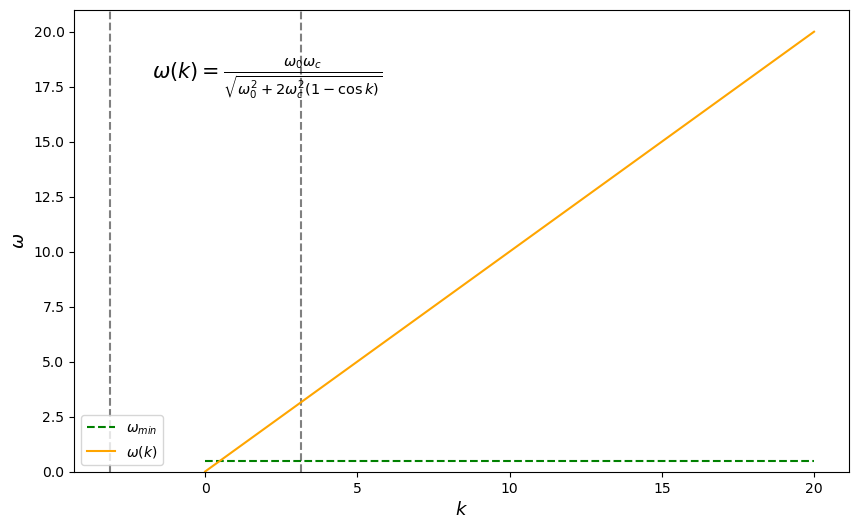

In [56]:
fig, ax = plt.subplots(figsize=[10, 6])
ax.set_ylim(-0.01, wc + wc/20)
ax.set_xlabel(r"$k$", fontsize=13)
ax.set_ylabel(r"$\omega$", fontsize=13)
ax.vlines(-np.pi, 0, wc + wc/20, color = "grey", ls = "--")
ax.vlines(np.pi, 0, wc + wc/20, color = "grey", ls = "--")
ax.hlines(w_min, k_list[0], k_list[-1], color = "green", ls = "--", label = r"$\omega_{min}$")
ax.plot(k_list, wk, color = "orange", label=r"$\omega(k)$")
ax.text(0.1, 0.85, r"$\omega(k)=\frac{\omega_0 \omega_c}{\sqrt{\omega_0^2 + 2\omega_c^2 (1-\cos{k})}}$", transform=ax.transAxes, fontsize=15)
ax.legend()

area_aprox = np.trapezoid(wk, k_list)
k_good = np.linspace(0, wc, 100000000)
# wk_good = w0 * wc / np.sqrt(w0**2 + 2 * wc**2 * (1 - np.cos(k_good)))
wk_good = np.abs(k_good)


area_good = np.trapezoid(wk_good, k_good)

print(area_aprox)
print(area_good)
print(f"Error {100 * np.abs(area_aprox - area_good)/ area_good}%")

In [ ]:
# Tabla Nk <---> wc de forma que el error en area <= 0.1 %

wc = 1000  Nk = 5001
wc = 100   Nk = 501
wc = 50   Nk = 301
wc = 10   Nk = 101
wc = 5   Nk = 101


In [1]:
import numpy as np
50/np.sqrt(1+4*50**2)

np.float64(0.4999750018748438)

# J(w)

In [6]:
w0 = SB_params["w0"]
wc = SB_params["wc"]
g = SB_params["g"]

w_list = np.arange(w_min + 0.001, wc-0.0000001, 0.000001)

Jw = 2 * g**2 * w0**2 / (w_list**3 * np.sqrt(1 - (1 - w0**2 * (1/w_list**2 - 1/wc**2) / 2)**2)) 
Jw

array([448.92809177, 448.36848868, 447.81096752, ...,   5.35075895,
         6.65456678,   9.88389202], shape=(49499624,))

/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


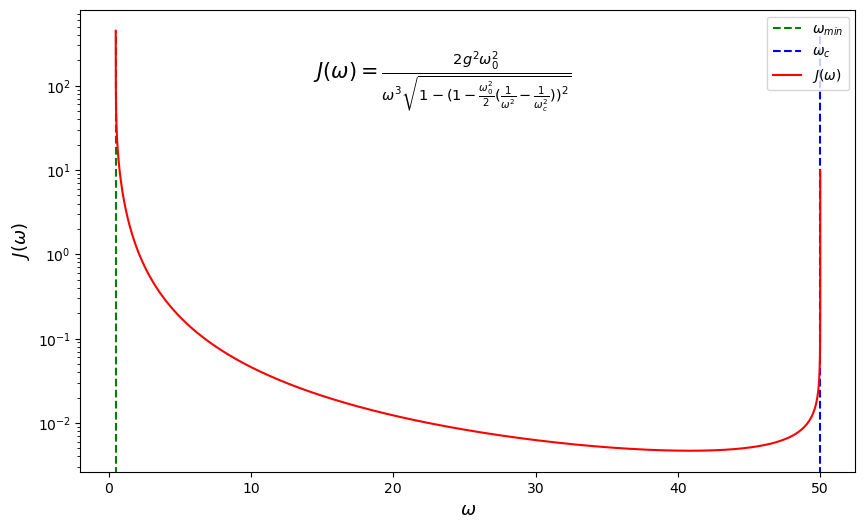

In [7]:
fig, ax = plt.subplots(figsize=[10, 6])
# ax.set_ylim(-0.01, wc + wc/20)
ax.set_xlabel(r"$\omega$", fontsize=13)
ax.set_ylabel(r"$J(\omega)$", fontsize=13)
ax.vlines(w_min, 0, max(Jw), color = "green", ls = "--", label=r"$\omega_{min}$")
ax.vlines(wc, 0, max(Jw), color = "blue", ls = "--", label=r"$\omega_c$")
# ax.vlines(np.pi, 0, wc + wc/20, color = "grey", ls = "--")

ax.plot(w_list, Jw, color = "red", label=r"$J(\omega)$")
ax.text(0.3, 0.85, r"$J(\omega)=\frac{ 2g^2\omega_0^2}{\omega^3\sqrt{1-(1-\frac{\omega_0^2}{2} (\frac{1}{\omega^2} - \frac{1}{\omega_c^2}))^2}} $", transform=ax.transAxes, fontsize=15)
ax.set_yscale("log")
ax.legend()

In [51]:
Nk = 101
wc = np.pi
g = 0.02
dk =  2 * np.pi / Nk
delta = 1.0
k = np.linspace(0, wc, Nk)

wk = np.abs(k)

alpha = g
gk = np.sqrt(alpha * delta * dk/2) * np.sqrt(wk)

Jwk =2* np.pi * gk**2 / (dk) 

wlist = np.linspace(0, 2* np.pi, 1000)
Jw = np.pi * alpha * wlist


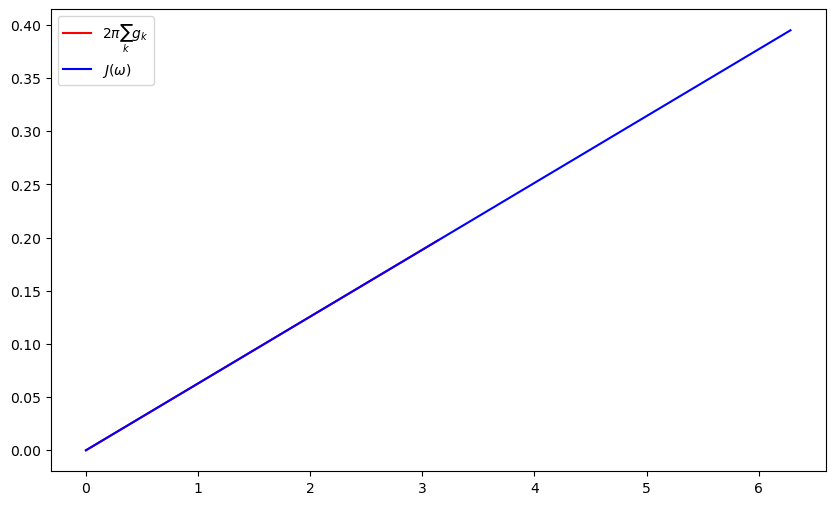

In [52]:
fig, ax = plt.subplots(figsize=[10, 6])

ax.plot(wk, Jwk, color = "red", label=r"$2\pi\sum_k g_k$")
ax.plot(wlist, Jw, color = "blue", label=r"$J(\omega)$")
ax.legend()

In [ ]:
""" GROUND STATE AND ENERGY """

initial_state = caa.InitialState(config=[], GS=False)
eng = TwoSiteDMRGEngine(initial_state, caa, config["DMRG_options"])
E_gr, psi_gr = eng.run()

/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


In [ ]:
# E_gr.append(E_run)                
#N=psi_gr.expectation_value(Caa.OperatorChain('N'),Caa.bs_idx)
Sz=psi_gr.expectation_value('Sz',caa.atpos_idx)
Sx=psi_gr.expectation_value('Sx',caa.atpos_idx)
Sy=psi_gr.expectation_value('Sy',caa.atpos_idx)
Sbond=psi_gr.entanglement_entropy(n=1)[0]
N = psi_gr.expectation_value(caa.OperatorChain("N"), caa.bs_idx)

print('E_run:%.2f '%E_gr)
print('Sz: ',Sz)
print('Sx',Sx)
print('Sy',Sy)
print('Entanglement_S:',Sbond,'\n\n')
print('N ocupation:',N,'\n')

E_run:-2.66 
Sz:  [-0.03014556]
Sx [1.45443524e-11]
Sy [0.]
Entanglement_S: 0.6913285676943391 


N ocupation: [2.26962478e+00 3.16270814e-01 9.67499390e-02 2.61491162e-02
 7.07633834e-03 1.91826937e-03 5.20651166e-04 1.39328734e-04
 3.53311788e-05 8.17586512e-06 1.69906852e-06 3.16244744e-07
 5.27827723e-08 7.91409935e-09 1.06771129e-09 1.29776276e-10
 1.42234732e-11 1.40638797e-12 1.25477134e-13 1.00998407e-14
 7.33081210e-16 4.79452419e-17 2.82251304e-18 1.49348752e-19
 6.92003307e-21 3.05995624e-22 1.84805143e-22 7.05781897e-24
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00

In [ ]:
C=psi_gr.correlation_function(caa.OperatorChain('Bd'),caa.OperatorChain('B'),caa.bs_idx,caa.bs_idx)

# Plots

In [ ]:
from pathlib import Path 
import matplotlib.pyplot as plt
import pickle as pkl
import matplotlib.transforms as transforms
import numpy as np

pickle_path = "/home/ihuarte/Escritorio/Ivan/MPS/Results/0bfd0944/Main_results_wc_5.0000_Nk_101.0000.pkl"
with open(pickle_path, "rb")  as f:
    data = pkl.load(f)


'ihuarte'

In [ ]:
sim_label = Path(pickle_path).name.split(".pkl")[0].split("Main_results_")[1]
new_folder = "Figures_" + sim_label
write_folder = str(Path(pickle_path).parent) + "/" + new_folder + "/"


'/home/ihuarte/Escritorio/Ivan/MPS/Results/0bfd0944/Figures_wc_5.0000_Nk_101.0000/'

# N/Nx Occ

/tmp/ipykernel_81348/4129657813.py:26: RuntimeWarning: divide by zero encountered in divide
  Nteo_1 = g**2 / (np.pi**2 * w0**2 *nprime**2) * (1 / n_values**4)
/tmp/ipykernel_81348/4129657813.py:28: RuntimeWarning: divide by zero encountered in divide
  Nteo_2 = g**2 / (2 * np.pi * w0**2 * nprime**2) * (np.exp(-2 * n_values / nprime) / n_values**3)


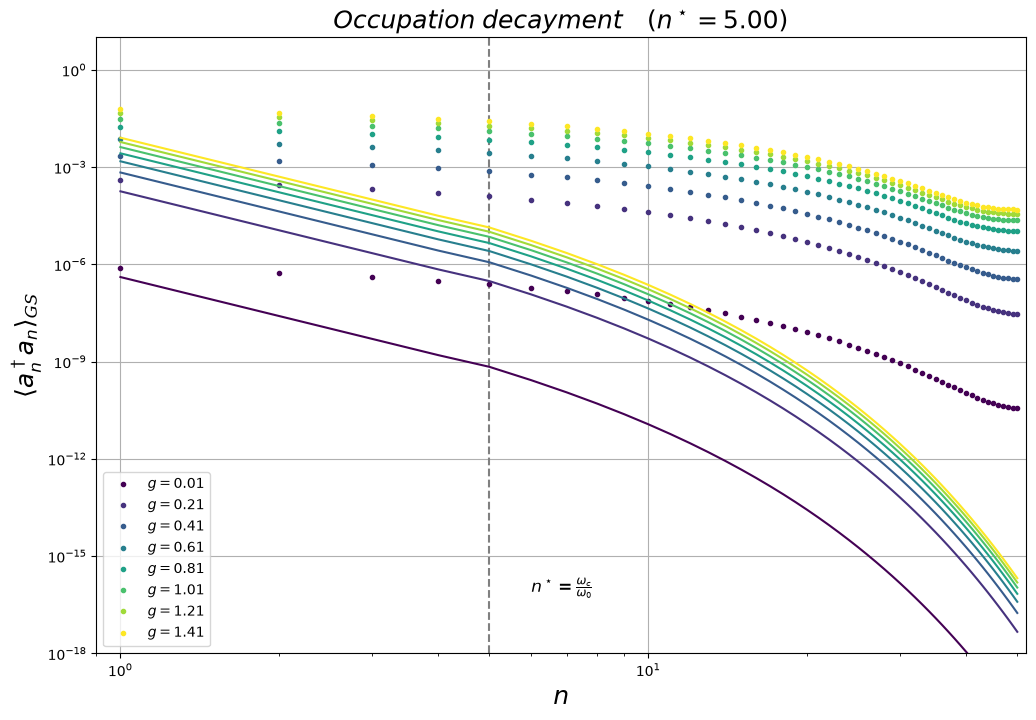

In [ ]:

w0 = int(data[:, 0][0])
wc = int(data[:, 1][0])
Nk = int(data[:, 2][0])
gvals = data[:, 3][::10]

nprime = wc / w0

fig1, ax1 = plt.subplots(figsize=[12,8])
ax1.set_title(r"$Occupation\;decayment \quad (n^\star=%.2f)$"%(nprime), fontsize=18)
ax1.set_xlabel(r"$n$", fontsize=18)
ax1.set_ylabel(r"$\langle a_n^\dagger a_n \rangle_{GS}$", fontsize=18)
ax1.set_ylim(1e-18, 1e1)
ax1.set_xlim(9e-1, Nk//2 +2)

ax1.vlines(nprime, 1e-18, 1e1, color="grey", ls="--")
ax1.text(nprime+1, 0.1, r"$n^\star = \frac{\omega_c}{\omega_0}$", transform=transforms.blended_transform_factory(ax1.transData, ax1.transAxes), fontsize = 12)
cmap = plt.colormaps["viridis"](np.linspace(0, 1, len(gvals)))

for i, g in enumerate(gvals):
    Nx = np.loadtxt("/home/ihuarte/Escritorio/Ivan/MPS/Results/0bfd0944/GroundState_wc_%.4f_g_%.4f_NoccX.txt"%(wc, g), dtype=complex).real
    Nxhalf = Nx[Nk//2:]
    n_values = np.arange(len(Nxhalf))
    
    # TEORIC
    # n < nprime
    Nteo_1 = g**2 / (np.pi**2 * w0**2 *nprime**2) * (1 / n_values**4) 
    # n > nprime
    Nteo_2 = g**2 / (2 * np.pi * w0**2 * nprime**2) * (np.exp(-2 * n_values / nprime) / n_values**3) 
    Nteo = np.concatenate([Nteo_1[1:int(nprime)], Nteo_2[int(nprime):]])
    ax1.plot(range(1, len(n_values)), Nteo, color=cmap[i] )

    # MPS RESULTS
    ax1.plot(range(len(Nxhalf)), Nxhalf, color=cmap[i], marker='o', ls="", ms = 3, label=r"$g=%.2f$"%g)

ax1.legend()
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.grid()


# Energy

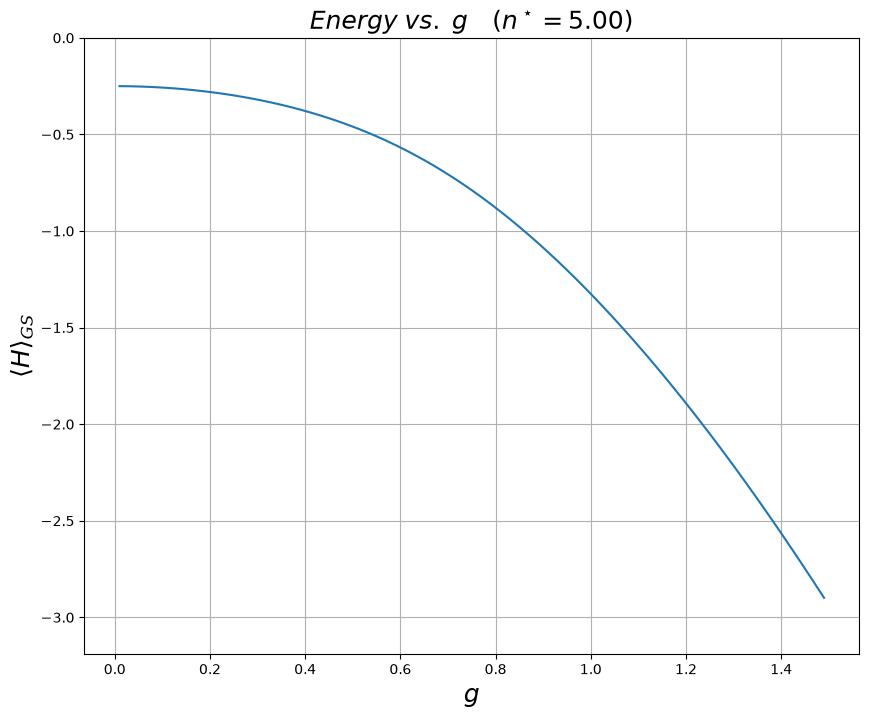

In [ ]:
gvals = data[:, 3]
E_gr = data[:, 4]


fig2, ax2 = plt.subplots(figsize=[10, 8])
ax2.set_title(r"$Energy\;vs.\;g \quad (n^\star=%.2f)$"%(nprime), fontsize=18)
ax2.set_xlabel(r"$g$", fontsize=18)
ax2.set_ylabel(r"$\langle H \rangle_{GS}$", fontsize=18)
ax2.set_ylim(min(E_gr)+min(E_gr)/10, max(E_gr)-max(E_gr))
ax2.grid()
ax2.plot(gvals, E_gr)


# Entropia

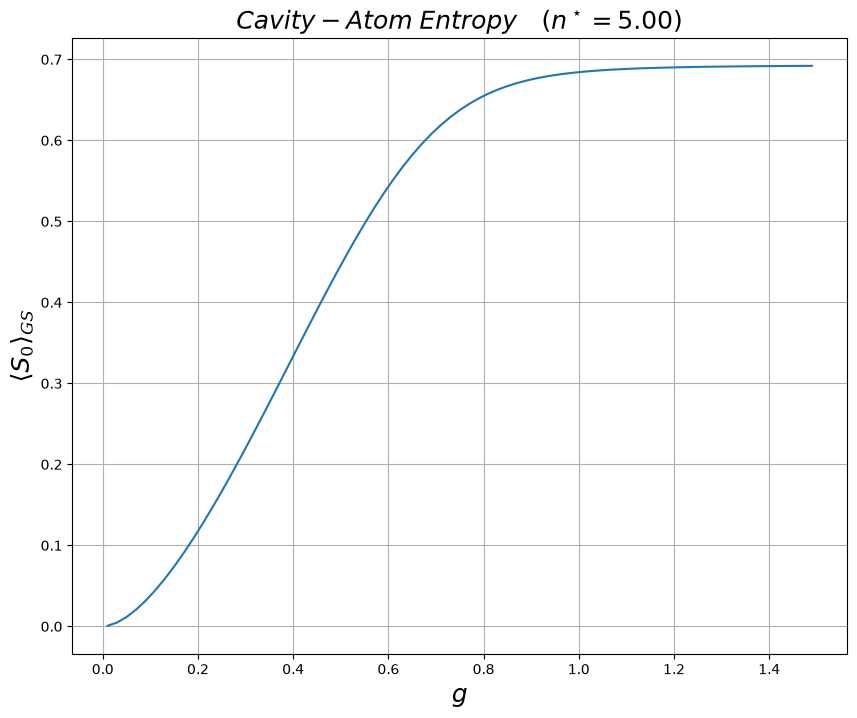

In [ ]:
w0 = data[:, 0][0]
wc = data[:, 1][0]
Nk = data[:, 2][0]
gvals = data[:, 3]

Sbond = data[:, 8]


fig3, ax3 = plt.subplots(figsize=[10, 8])
ax3.set_title(r"$Cavity-Atom\;Entropy  \quad (n^\star=%.2f)$"%(nprime), fontsize=18)
ax3.set_xlabel(r"$g$", fontsize=18)
ax3.set_ylabel(r"$\langle S_0 \rangle_{GS}$", fontsize=18)
# ax3.set_ylim(min(E_gr)+min(E_gr)/10, max(E_gr)-max(E_gr))
ax3.grid()
ax3.plot(gvals, Sbond)


# SPIN

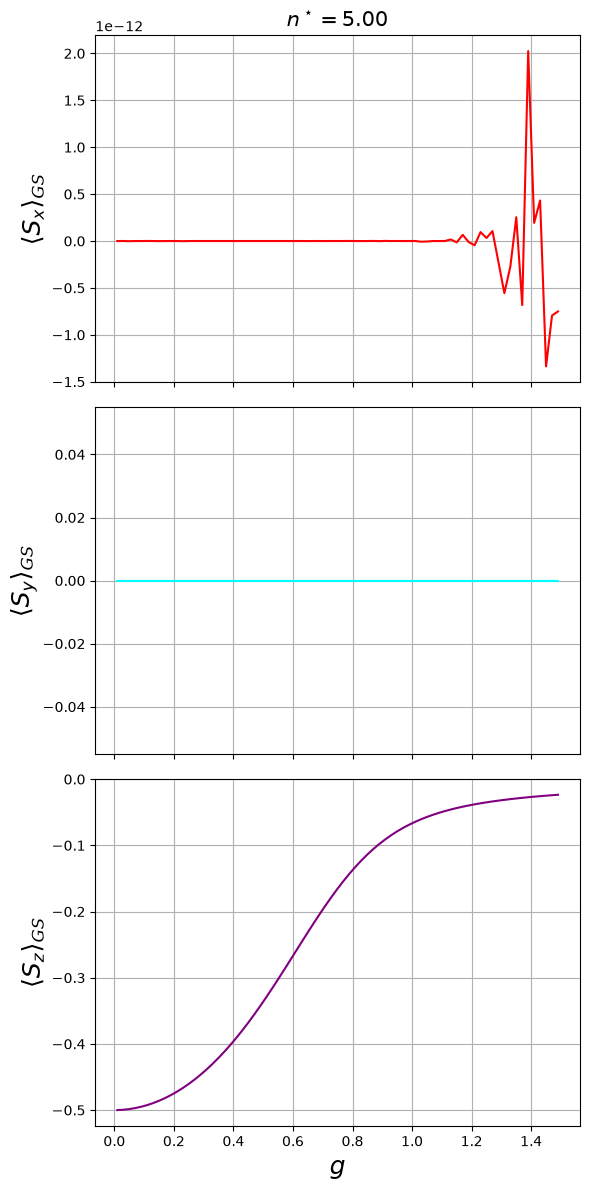

In [ ]:
gvals = data[:, 3]
Sz = data[:, 5]
Sx = data[:, 6]
Sy = data[:, 7]


fig4, ax4 = plt.subplots(3, 1, figsize=[6,12])
ax4[0].set_title(r"$n^\star=%.2f$"%(nprime), fontsize=15)

ax4[0].set_ylabel(r"$\langle S_x \rangle_{GS}$", fontsize=18)
ax4[1].set_ylabel(r"$\langle S_y \rangle_{GS}$", fontsize=18)
ax4[2].set_ylabel(r"$\langle S_z \rangle_{GS}$", fontsize=18)
ax4[0].set_xticklabels([])
ax4[1].set_xticklabels([])
ax4[2].set_xlabel(r"$g$", fontsize=18)

ax4[0].plot(gvals, Sx, color="r")
ax4[1].plot(gvals, Sy, color="cyan")
ax4[2].plot(gvals, Sz, color="purple")

ax4[0].grid()
ax4[1].grid()
ax4[2].grid()

plt.tight_layout()

In [ ]:
glob.glob("/home/ihuarte/Escritorio/Ivan/MPS/Results/**/*.pkl", recursive=True)

['/home/ihuarte/Escritorio/Ivan/MPS/Results/0bfd0944/Main_results_wc_5.0000_Nk_101.0000.pkl',
 '/home/ihuarte/Escritorio/Ivan/MPS/Results/0bfd0944/Main_results_wc_0.5000_Nk_101.0000.pkl',
 '/home/ihuarte/Escritorio/Ivan/MPS/Results/0bfd0944/Main_results_wc_1.0000_Nk_101.0000.pkl']